# Moderación semiautomática de videos peruanos de YouTube mediante modelos clásicos y neuronales de procesamiento del lenguaje natural

**Trabajo final del curso de Procesamiento de Lenguaje Natural (PLN) de la Maestría en Inteligencia Artificial de la Universidad Nacional de Ingeniería (UNI) — Semestre 2026-1**

**Grupo 4:** Luis Enrique Koc Góngora, Alex Felipe Mancilla Antay, Herbert Antonio Meléndez García y Dennis Jack Paitán Cano

---

## 03.07a · Reporte local de comparación de modelos

Consulta automáticamente la publicación 03_07 en Google Drive, la compara con el estado local por fecha y SHA-256, descarga solo resultados cuando corresponde y publica tablas, figuras y un informe Markdown crítico. Usa OAuth de solo lectura, no Drive Desktop; no extrae pesos y no abre test.

Balanced accuracy evita que el desbalance de clases oculte el desempeño de ANY_DAMAGE [1], mientras AUPRC aporta una lectura apropiada para categorías minoritarias [2]. Las pruebas y decisiones permanecen separadas de test para evitar sesgo de selección [3]. La síntesis presenta todas las métricas y explicita incertidumbre, capacidad de revisión y limitaciones; no convierte un orden lexicográfico en superioridad universal.

**Contrato de etiquetas v2.1:** cinco salidas entrenadas: `SEGURO`, `RACISMO_DISCRIMINACION`, `ATAQUE_POR_GENERO_IDENTIDAD`, `ACOSO_AMENAZA` y `CONTENIDO_SEXUAL`. `SEGURO` es excluyente; las cuatro categorías de daño son multietiqueta y pueden coexistir. Los casos indeterminados se difieren y no entran al entrenamiento. Esta combinación, sus umbrales y sus reglas de exclusividad son decisiones operativas locales.

## Reproducibilidad

El cuaderno solo orquesta funciones versionadas de `src/moderacion_peru`. En local no instala paquetes. En Colab, únicamente la celda de bootstrap instala versiones fijadas desde el bundle SHA-256 de Drive. No usa rutas personales. Revise el README de esta etapa.

In [1]:
from pathlib import Path
import sys

def find_root(start=Path.cwd()):
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise FileNotFoundError('No se encontró pyproject.toml')

ROOT = find_root()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
from moderacion_peru.notebook_ui import notebook_progress, run_with_progress, show_callout, show_command, show_result, show_summary, show_table
OPERATIONAL_PROMPT=ROOT/'config/prompt_operacional_ollama_v3_2.md'
if not OPERATIONAL_PROMPT.is_file():
    raise FileNotFoundError(f'Falta el prompt operacional vigente: {OPERATIONAL_PROMPT}')
show_summary('Entorno del proyecto', {'raíz': ROOT, 'backend': 'local', 'prompt_operacional': OPERATIONAL_PROMPT}, tone='success')


raíz,C:/usr/ths_mia_fiis/pln/trabajo
backend,local
prompt_operacional,C:/usr/ths_mia_fiis/pln/trabajo/config/prompt_operacional_ollama_v3_2.md


## Sincronización automática y verificable desde Google Drive

La primera ejecución requiere un cliente OAuth de tipo **aplicación de escritorio** para la Google Drive API. Descargue su JSON como `config/google_drive_oauth_client.json`; esta ruta y el token `.secrets/google_drive_token.json` están ignorados por Git. Al ejecutar, el navegador solicitará una sola vez acceso de solo lectura. Las ejecuciones posteriores comparan el manifiesto remoto con el local y solo descargan una publicación nueva o diferente. Si aún no se configuró OAuth, la celda conserva el reporte local y muestra el paso pendiente. La preparación está documentada en `docs/GOOGLE_DRIVE_03_07A.md`.

In [ ]:
from moderacion_peru.comparison_reporting import synchronize_google_drive_results, synchronize_latest_local_results

# OAuth usa permiso Drive de solo lectura. La primera autorización abre el navegador;
# después reutiliza el token local ignorado por Git. Nunca usa Drive Desktop.
AUTO_SYNC_FROM_GOOGLE_DRIVE=False
INTERACTIVE_GOOGLE_DRIVE_AUTH=False
SEARCH_ROOTS=(
    ROOT/'resultados/sincronizados/03_07',
    ROOT/'resultados/modelos',
)
drive_sync_result=None
if AUTO_SYNC_FROM_GOOGLE_DRIVE:
    try:
        drive_sync_result=run_with_progress(
            'Consulta y sincronización automática desde Google Drive',
            synchronize_google_drive_results,
            ROOT,
            interactive_auth=INTERACTIVE_GOOGLE_DRIVE_AUTH,
            progress_unit='publicación',
        )
        sync_result=drive_sync_result
        show_result('Estado remoto de Google Drive',drive_sync_result,tone='success')
    except (FileNotFoundError,PermissionError) as exc:
        show_callout(
            'Autorización de Drive pendiente',
            f'{exc} Se continuará con los resultados locales; complete la autorización y repita esta celda para activar la actualización remota.',
            tone='warning',
        )
        sync_result=run_with_progress(
            'Selección de la comparación local más reciente',
            synchronize_latest_local_results,
            ROOT,
            search_roots=SEARCH_ROOTS,
            progress_unit='fuente',
        )
else:
    sync_result=run_with_progress(
        'Selección de la comparación local más reciente',
        synchronize_latest_local_results,
        ROOT,
        search_roots=SEARCH_ROOTS,
        progress_unit='fuente',
    )
show_result('Resultados 03_07 sincronizados localmente',sync_result,tone='success')

Consulta y sincronización automática desde Google Drive:   0%|          | 0/1 [00:00<?, ?publicación/s]

Selección de la comparación local más reciente:   0%|          | 0/1 [00:00<?, ?fuente/s]

status,synchronized
comparison_path,C:\usr\ths_mia_fiis\pln\trabajo\resultados\modelos\comparacion_individual_ensemble_validation.json
freeze_path,C:\usr\ths_mia_fiis\pln\trabajo\resultados\modelos\seleccion_congelada.json
manifest_path,C:\usr\ths_mia_fiis\pln\trabajo\resultados\modelos\sincronizacion_03_07.json
comparison_signature,ca06c9d74d95ccc33555e365186bfe07c57bad273e2f53d86c5451aab07e5baf
source_created_at,2026-08-15T04:28:43.105012+00:00
ranking_count,33
selected_id,ensemble_soft_mean
has_test,No


## Reporte tabular, gráfico y crítico

Tablas, figuras y análisis crítico:   0%|          | 0/1 [00:00<?, ?reporte/s]

seleccionado,ensemble_soft_mean
estado_inferencial,statistical_tie_or_inconclusive
test_disponible,No
reporte_markdown,C:\usr\ths_mia_fiis\pln\trabajo\resultados\modelos\REPORTE_COMPARACION_MODELOS_03_07.md
tablas,"Ver detalle{ ""ranking_validation"": ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\tablas_03_07a\\ranking_validation.csv"", ""categories_validation"": ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\tablas_03_07a\\metricas_por_categoria_validation.csv"", ""category_winners"": ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\tablas_03_07a\\ganadores_por_categoria_validation.csv"", ""paired_bootstrap"": ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\tablas_03_07a\\comparaciones_bootstrap_pareadas.csv"" }"
figuras,"Ver detalle[ ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\figuras_03_07a\\ranking_global_validation.png"", ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\figuras_03_07a\\seleccion_por_categoria_validation.png"", ""C:\\usr\\ths_mia_fiis\\pln\\trabajo\\resultados\\modelos\\figuras_03_07a\\frontera_ba_macro_auprc_validation.png"" ]"


rank,candidate_id,kind,model_family,training_regime,members,balanced_accuracy_any_damage_oof,fnr_any_damage_oof,fpr_any_damage_oof,risk_0_67_oof,f1_any_damage_oof,auprc_any_damage_oof,macro_auprc_damage_oof,macro_auprc_damage_deployment,macro_f1_damage,macro_f1_five,micro_f1,false_safe_rate_on_damage,false_alarm_rate_on_safe,ece,brier_macro,review_policy_status,review_load_rate,macro_auprc_safeguard,macro_auprc_difference_vs_reference,selected
1,ensemble_soft_mean,ensemble,ensemble,ensemble_of_reported_members,classical-logistic_regression_c0p5-54f7971c6000; cascade_v2-af78eba77883; qwen_lora-4aa5ce04df05,0.8399764150943396,0.12735849056603776,0.192688679245283,0.14891745283018867,0.6602426837972877,0.7127555874899013,0.5549281667336825,0.5653218176719818,0.5682777187873591,0.6389674400955873,0.8419533948323351,0.4900943396226415,0.07830188679245283,0.011686793695392534,0.04718043652506741,selected_on_validation_under_capacity,0.32537735849056604,pass,0.03215960811748053,Sí
2,ensemble_soft_validation_weighted,ensemble,ensemble,ensemble_of_reported_members,classical-logistic_regression_c0p5-54f7971c6000; cascade_v2-af78eba77883; qwen_lora-4aa5ce04df05,0.8383254716981132,0.13396226415094337,0.1893867924528302,0.152252358490566,0.6601941747572816,0.7140139603969733,0.5560420801142318,0.5664030791219115,0.5693918693537869,0.6398996898311277,0.840840578443794,0.4716981132075472,0.08089622641509434,0.011517341985866757,0.047033132981765965,selected_on_validation_under_capacity,0.2960377358490566,pass,0.03327352149802987,No
3,ensemble_union,ensemble,ensemble,ensemble_of_reported_members,classical-logistic_regression_c0p5-54f7971c6000; cascade_v2-af78eba77883; qwen_lora-4aa5ce04df05,0.8327830188679246,0.17169811320754713,0.16273584905660377,0.16874056603773582,0.6681887366818874,0.6844038234575305,0.5235999652756183,0.5497575374309394,0.5648339325747971,0.6359988998882111,0.8362857017889166,0.405188679245283,0.09858490566037736,0.015565824111816636,0.04996800898376399,selected_on_validation_under_capacity,0.30160377358490564,pass,0.0008314066594162783,No
4,qwen_lora-4aa5ce04df05,individual,qwen_lora,standard,qwen_lora-4aa5ce04df05,0.8313679245283019,0.16981132075471694,0.1674528301886793,0.16903301886792452,0.6641509433962264,0.6918514077360827,0.5157547221950667,0.5422229249434646,0.5534388227129415,0.6271733120933204,0.8408569917122201,0.455188679245283,0.08608490566037735,0.011675978685384027,0.04897496910369305,selected_on_validation_under_capacity,0.23707547169811322,pass,-0.007013836421135289,No
5,qwen_lora-context256_from128-009a589e6574,individual,qwen_lora,standard,qwen_lora-context256_from128-009a589e6574,0.8297759433962264,0.1419811320754717,0.1984669811320755,0.16062146226415094,0.6471006759160441,0.6867740246219491,0.522768558616202,0.5564892250256057,0.5716331169494592,0.642099806281427,0.8434358951850064,0.43254716981132074,0.09622641509433963,0.01102107883098175,0.04832392899433201,selected_on_validation_under_capacity,0.2521698113207547,pass,0.0,No
6,qwen_lora-context256_from128-1353d08f2963,individual,qwen_lora,standard,qwen_lora-context256_from128-1353d08f2963,0.8297759433962264,0.1419811320754717,0.1984669811320755,0.16062146226415094,0.6471006759160441,0.6867740246219491,0.522768558616202,0.5564892250256057,0.5716331169494592,0.642099806281427,0.8434358951850064,0.43254716981132074,0.09622641509433963,0.01102107883098175,0.04832392899433201,selected_on_validation_under_capacity,0.2521698113207547,pass,0.0,No
7,ensemble_hard_majority,ensemble,ensemble,ensemble_of_reported_members,classical-logistic_regression_c0p5-54f7971c6000; cascade_v2-af78eba77883; qwen_lora-4aa5ce04df05,0.8287735849056603,0.17877358490566042,0.16367924528301891,0.17379245283018874,0.6633644503714994,0.6525640859107796,0.4605597768654038,0.4537197933032065,0.5723108641903628,0.6419116692080982,0.844409143058865,0.4962264150943396,0.07382075471698113,0.010620585150665312,0.0499451866948607,selected_on_validation_under_capacity,0.1638679245283019

rank_global,candidate_id,kind,model_family,macro_auprc_safeguard,label,average_precision,precision,recall,f1,support,ece,brier,selected
1,ensemble_soft_mean,ensemble,ensemble,pass,SEGURO,0.9743594109753091,0.8867698343504795,0.9595518867924528,0.9217263253285002,8480,0.03905311443132484,0.09394811385398372,Sí
1,ensemble_soft_mean,ensemble,ensemble,pass,RACISMO_DISCRIMINACION,0.5664320577583037,0.5776255707762558,0.662303664921466,0.6170731707317073,382,0.004705765594968297,0.021079316339953375,Sí
1,ensemble_soft_mean,ensemble,ensemble,pass,ATAQUE_POR_GENERO_IDENTIDAD,0.39431769112669035,0.40501043841336115,0.5187165775401069,0.4548651817116061,374,0.004091122519895096,0.026330733279463458,Sí
1,ensemble_soft_mean,ensemble,ensemble,pass,ACOSO_AMENAZA,0.6128956223890236,0.5444444444444444,0.5986038394415357,0.5702410640066501,1146,0.012809220325358124,0.06325149113077028,Sí
1,ensemble_soft_mean,ensemble,ensemble,pass,CONTENIDO_SEXUAL,0.6876418994139093,0.7108910891089109,0.5671406003159558,0.6309314586994728,633,0.008908162453854207,0.03129252802116623,Sí


label,best_average_precision_model,best_average_precision,best_f1_model,best_f1,best_recall_model,best_recall,precision_at_best_recall,support
SEGURO,ensemble_soft_validation_weighted,0.9744713404670637,qwen_lora-context256_from128-009a589e6574,0.9239665636092981,classical-linear_svm_c2-54f7971c6000,0.9665094339622642,0.8640101201771031,8480
RACISMO_DISCRIMINACION,qwen_lora-context256_from128-009a589e6574,0.5711290636352615,qwen_lora-context256_from128-009a589e6574,0.6221692491060786,qwen_lora-context256_from128-009a589e6574,0.6832460732984293,0.5711159737417943,382
ATAQUE_POR_GENERO_IDENTIDAD,qwen_lora-context256_from128-009a589e6574,0.40169827422094584,ensemble_hard_majority,0.46954314720812185,ensemble_soft_validation_weighted,0.553475935828877,0.3883677298311445,374
ACOSO_AMENAZA,ensemble_soft_validation_weighted,0.6142885869837322,ensemble_union,0.5839357429718876,ensemble_union,0.6343804537521816,0.5409226190476191,1146
CONTENIDO_SEXUAL,ensemble_soft_mean,0.6876418994139093,ensemble_union,0.6382306477093207,ensemble_union,0.6382306477093207,0.6382306477093207,633


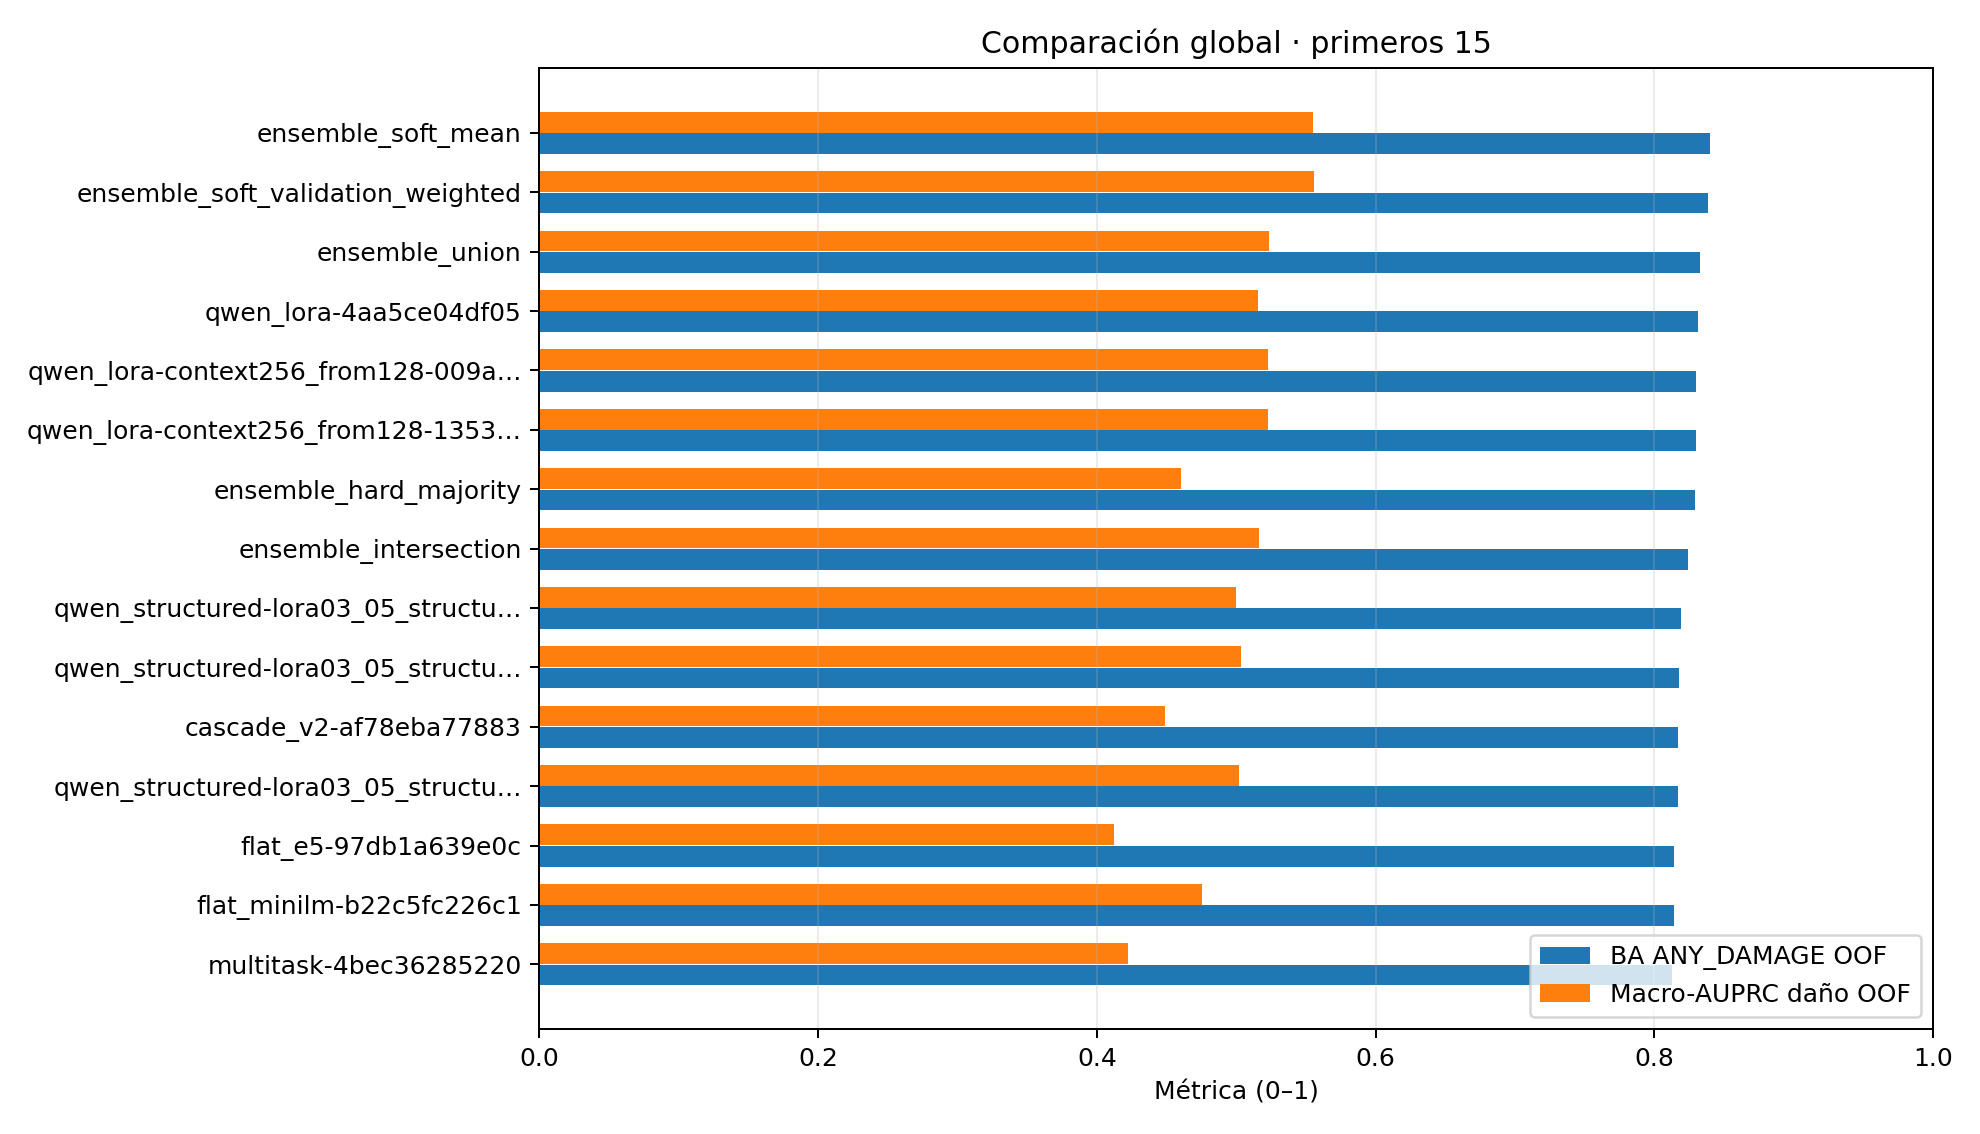

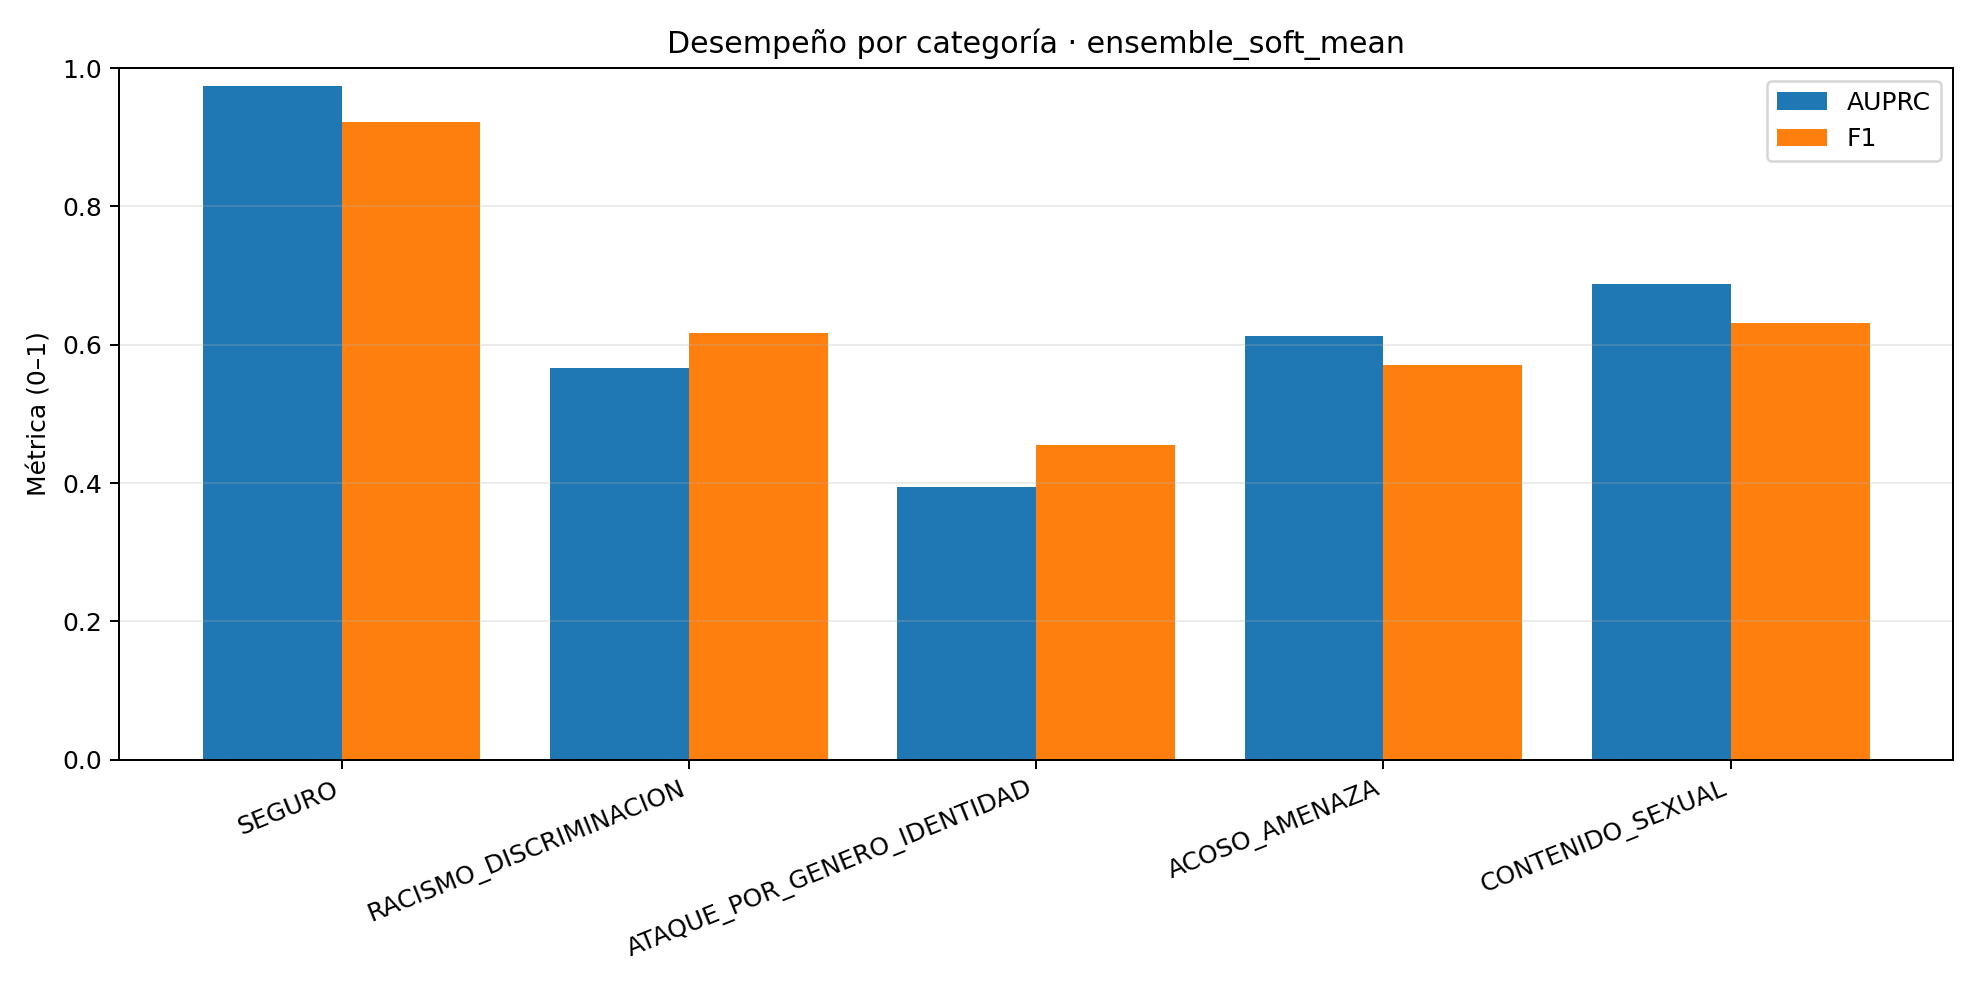

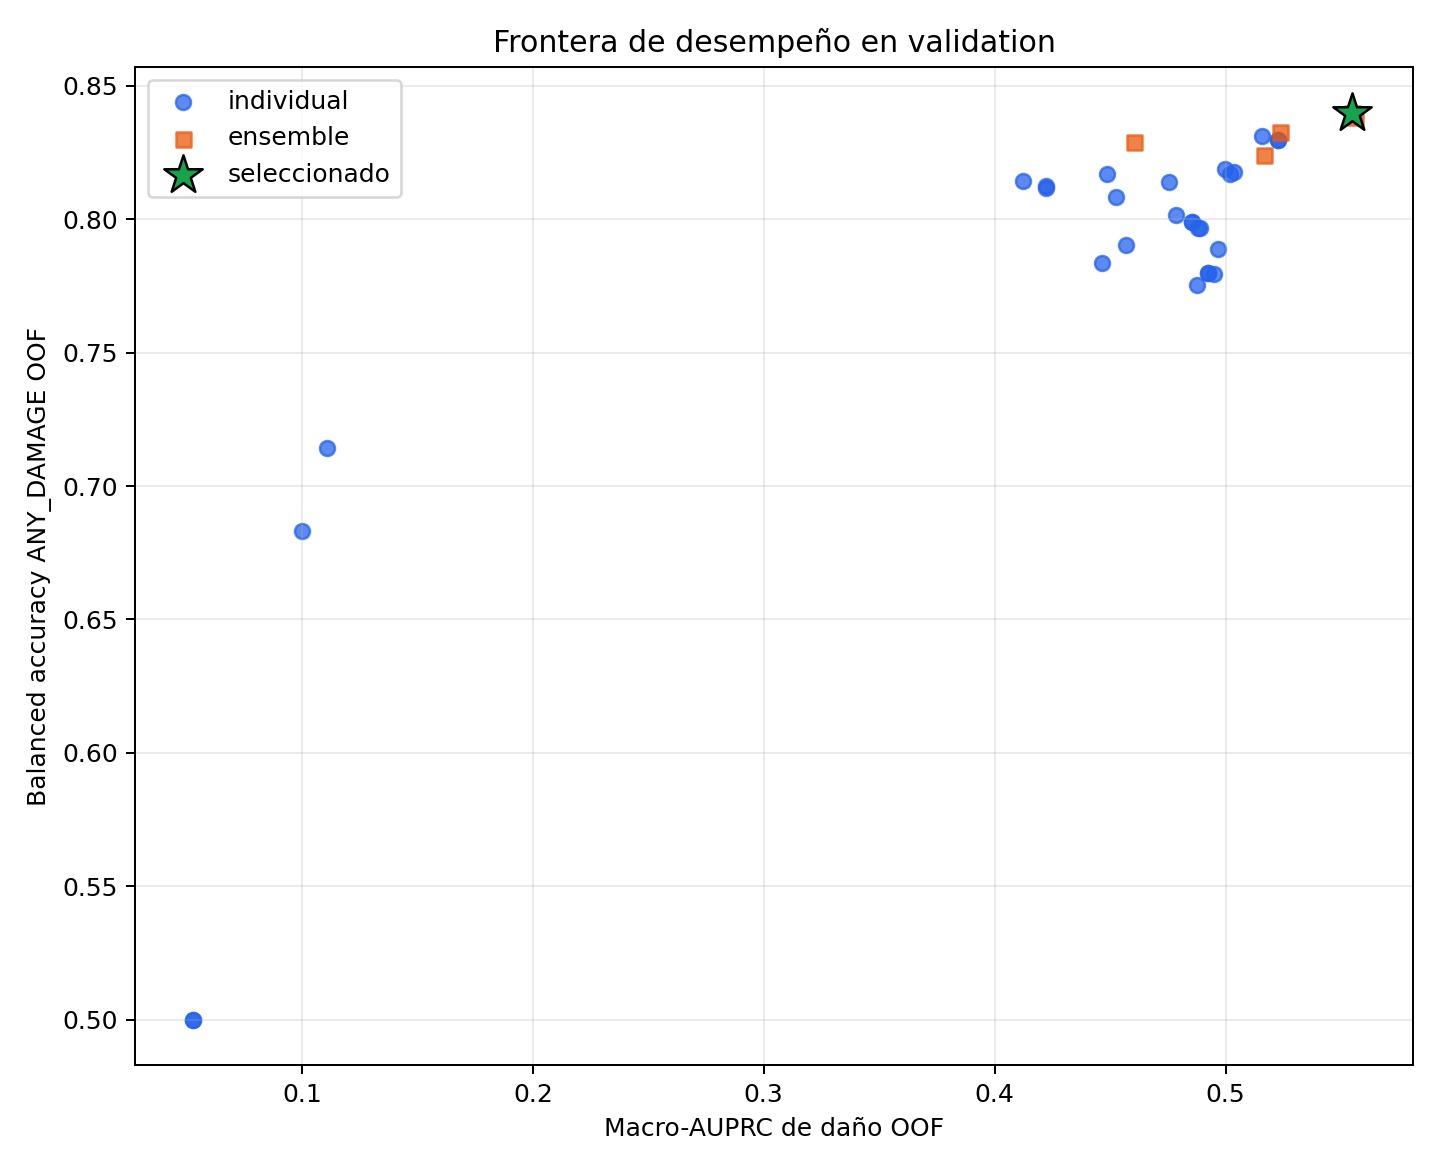

In [3]:
from IPython.display import Image, display
from moderacion_peru.comparison_reporting import generate_comparison_report

report_result=run_with_progress(
    'Tablas, figuras y análisis crítico',
    generate_comparison_report,
    sync_result['comparison_path'],
    freeze_path=sync_result.get('freeze_path'),
    test_path=sync_result.get('test_path'),
    output_dir=ROOT/'resultados/modelos',
    generate_figures=True,
    progress_unit='reporte',
)
show_summary('Reporte reproducible 03_07a',{
    'seleccionado':report_result['selected_id'],
    'estado_inferencial':report_result['winner_status'],
    'test_disponible':report_result['test_available'],
    'reporte_markdown':report_result['report_path'],
    'tablas':report_result['table_paths'],
    'figuras':report_result['figure_paths'],
},tone='success')
show_table('Ranking global completo',report_result['global_rows'],max_rows=40)
show_table('Mejor modelo por tipo',report_result['best_by_model_type_rows'],max_rows=4)
show_table('Seleccionado por categoría',report_result['selected_category_rows'],max_rows=10)
show_table('Mejores candidatos por categoría',report_result['category_winners'],max_rows=10)
for figure_path in report_result['figure_paths']:
    display(Image(filename=figure_path,width=1050))

## Referencias

[1] K. H. Brodersen, C. S. Ong, K. E. Stephan, et al., "The Balanced Accuracy and Its Posterior Distribution," in Proc. 20th Int. Conf. Pattern Recognition, 2010, pp. 3121–3124, doi: 10.1109/ICPR.2010.764.

[2] T. Saito and M. Rehmsmeier, "The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets," PLOS ONE, vol. 10, no. 3, Art. no. e0118432, 2015, doi: 10.1371/journal.pone.0118432.

[3] G. C. Cawley and N. L. C. Talbot, "On Over-Fitting in Model Selection and Subsequent Selection Bias in Performance Evaluation," J. Mach. Learn. Res., vol. 11, pp. 2079–2107, 2010.